In [33]:
import os
import json
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, Masking
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

In [35]:
DATASET_DIR = "dataset2"
SEQ_LEN = 50
FEATURES = 225

In [36]:
X, y = [], []

def normalize_landmarks(left, right, pose):
    """
    Normalize landmarks:
    1. Centering: subtract a reference point (shoulder center for pose, wrist for hands)
    2. Scaling: divide by shoulder distance (to make invariant to person size / camera distance)
    """

    # Default zeros if empty
    left_coords = [0.0] * 63
    right_coords = [0.0] * 63
    pose_coords = [0.0] * 99

    # --- Pose normalization ---
    if pose:
        try:
            lx, ly, lz = pose[11]["x"], pose[11]["y"], pose[11]["z"]  # left shoulder
            rx, ry, rz = pose[12]["x"], pose[12]["y"], pose[12]["z"]  # right shoulder
            cx, cy, cz = (lx + rx) / 2, (ly + ry) / 2, (lz + rz) / 2  # center point
            shoulder_dist = np.sqrt((rx - lx) ** 2 + (ry - ly) ** 2 + (rz - lz) ** 2)
            if shoulder_dist == 0:
                shoulder_dist = 1e-6  # avoid divide by zero

            pose_coords = [((lm["x"] - cx) / shoulder_dist,
                            (lm["y"] - cy) / shoulder_dist,
                            (lm["z"] - cz) / shoulder_dist) for lm in pose]
            pose_coords = [v for lm in pose_coords for v in lm]
        except Exception:
            pass

    # --- Left hand normalization ---
    if left:
        wrist = left[0]  # wrist is id=0
        wx, wy, wz = wrist["x"], wrist["y"], wrist["z"]
        left_coords = [(lm["x"] - wx, lm["y"] - wy, lm["z"] - wz) for lm in left]
        left_coords = [v for lm in left_coords for v in lm]

    # --- Right hand normalization ---
    if right:
        wrist = right[0]
        wx, wy, wz = wrist["x"], wrist["y"], wrist["z"]
        right_coords = [(lm["x"] - wx, lm["y"] - wy, lm["z"] - wz) for lm in right]
        right_coords = [v for lm in right_coords for v in lm]

    return left_coords, right_coords, pose_coords


# --- Load dataset ---
for label_name in os.listdir(DATASET_DIR):
    label_path = os.path.join(DATASET_DIR, label_name)
    if not os.path.isdir(label_path):
        continue
    print(f"Processing label: {label_name}")

    for file in os.listdir(label_path):
        if not file.endswith(".json"):
            continue

        with open(os.path.join(label_path, file), "r") as f:
            data = json.load(f)

        seq = []
        for frame in data:
            left = frame.get("left", [])
            right = frame.get("right", [])
            pose = frame.get("pose", [])

            # normalize here
            left_coords, right_coords, pose_coords = normalize_landmarks(left, right, pose)

            features = left_coords + right_coords + pose_coords  # (225,)
            seq.append(features)

        seq = np.array(seq)

        # Pad/trim to SEQ_LEN
        if len(seq) < SEQ_LEN:
            pad = np.zeros((SEQ_LEN - len(seq), FEATURES))
            seq = np.vstack([seq, pad])
        else:
            seq = seq[:SEQ_LEN]

        X.append(seq)
        y.append(label_name)

X = np.array(X)
y = np.array(y)

print("Final dataset shape: ", X.shape, y.shape)

Processing label: After
Processing label: Again
Processing label: Arm
Processing label: Back
Processing label: Before
Processing label: Chest
Processing label: Close
Processing label: Cough
Processing label: Difficult
Processing label: Drink
Processing label: Eye
Processing label: Finger
Processing label: Hand
Processing label: Head
Processing label: Hear
Processing label: Heart
Processing label: Help
Processing label: Hold
Processing label: Less
Processing label: More
Processing label: Mouth
Processing label: Move
Processing label: Nose
Processing label: Open
Processing label: Pain
Processing label: Read
Processing label: Rest
Processing label: Run
Processing label: See
Processing label: Shoulder
Processing label: Skin
Processing label: Sleep
Processing label: Sorry
Processing label: Stand
Processing label: Talk
Processing label: Thank You
Processing label: Throat
Processing label: Today
Processing label: Tomorrow
Processing label: Tongue
Processing label: Touch
Processing label: Walk

In [37]:
np.save("X.npy", X)
np.save("y.npy", y)
print("✅ Saved X.npy and y.npy")

✅ Saved X.npy and y.npy


In [38]:
X = np.load("X.npy")
y = np.load("y.npy")
print("Dataset shape:", X.shape, y.shape)

Dataset shape: (2200, 50, 225) (2200,)


In [39]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_cat = to_categorical(y_encoded, num_classes=len(le.classes_))

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, stratify=y_cat, random_state=42
)
np.save("X_train.npy", X_train)
np.save("X_test.npy", X_test)
np.save("y_train.npy", y_train)
np.save("y_test.npy", y_test)
print("✅ Saved train/test splits")

✅ Saved train/test splits


In [41]:
model = Sequential([
    Masking(mask_value=0.0, input_shape=(X.shape[1], X.shape[2])),
    Bidirectional(LSTM(256, return_sequences=True)),
    Dropout(0.4),
    Bidirectional(LSTM(256)),
    Dropout(0.4),
    Dense(256, activation="relu"),
    Dropout(0.3),
    Dense(len(le.classes_), activation="softmax")
])

In [44]:
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

In [46]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    ModelCheckpoint("best_sign_model_v2.h5", save_best_only=True)
]

In [47]:
import time
start_time = time.time()
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=60,
    batch_size=32,
    callbacks=callbacks
)
end_time = time.time()
training_time = end_time - start_time
print(f"\n✅ Training completed in {training_time:.2f} seconds ({training_time/60:.2f} minutes)")

Epoch 1/60
55/55 [==============================] - 12s 107ms/step - loss: 3.4476 - accuracy: 0.0722 - val_loss: 2.7557 - val_accuracy: 0.1523
Epoch 2/60
55/55 [==============================] - 3s 56ms/step - loss: 2.2888 - accuracy: 0.3011 - val_loss: 1.6409 - val_accuracy: 0.4409
Epoch 3/60
55/55 [==============================] - 3s 55ms/step - loss: 1.4690 - accuracy: 0.5358 - val_loss: 1.1449 - val_accuracy: 0.6500
Epoch 4/60
55/55 [==============================] - 3s 55ms/step - loss: 1.0083 - accuracy: 0.6687 - val_loss: 1.0854 - val_accuracy: 0.6500
Epoch 5/60
55/55 [==============================] - 3s 55ms/step - loss: 0.8569 - accuracy: 0.7063 - val_loss: 0.7652 - val_accuracy: 0.7205
Epoch 6/60
55/55 [==============================] - 3s 54ms/step - loss: 0.7412 - accuracy: 0.7386 - val_loss: 0.7083 - val_accuracy: 0.7841
Epoch 7/60
55/55 [==============================] - 3s 54ms/step - loss: 0.5599 - accuracy: 0.8040 - val_loss: 0.6816 - val_accuracy: 0.7795
Epoch 8/60


In [48]:
model.save("sign_model_v9.h5")
with open("label_encoder_v9.pkl", "wb") as f:
    pickle.dump(le, f)

print("✅ Training complete. Model saved as sign_model_v9.h5")

✅ Training complete. Model saved as sign_model_v9.h5


In [49]:
from tensorflow.keras.models import load_model
import pickle
# Load model and encoder
model = load_model("sign_model_v9.h5")

with open("label_encoder_v9.pkl", "rb") as f:
    le = pickle.load(f)

In [50]:
from sklearn.metrics import classification_report
import numpy as np

# Predict on test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print(classification_report(y_true_classes, y_pred_classes, target_names=le.classes_))

14/14 [==============================] - 3s 30ms/step
              precision    recall  f1-score   support

       After       1.00      0.50      0.67        10
       Again       1.00      1.00      1.00        10
         Arm       1.00      1.00      1.00        10
        Back       1.00      1.00      1.00        10
      Before       1.00      1.00      1.00        10
       Chest       0.91      1.00      0.95        10
       Close       1.00      1.00      1.00        10
       Cough       0.91      1.00      0.95        10
   Difficult       1.00      1.00      1.00        10
       Drink       1.00      1.00      1.00        10
         Eye       1.00      1.00      1.00        10
      Finger       1.00      1.00      1.00        10
        Hand       1.00      1.00      1.00        10
        Head       1.00      1.00      1.00        10
        Hear       0.91      1.00      0.95        10
       Heart       1.00      0.90      0.95        10
        Help       0.83    

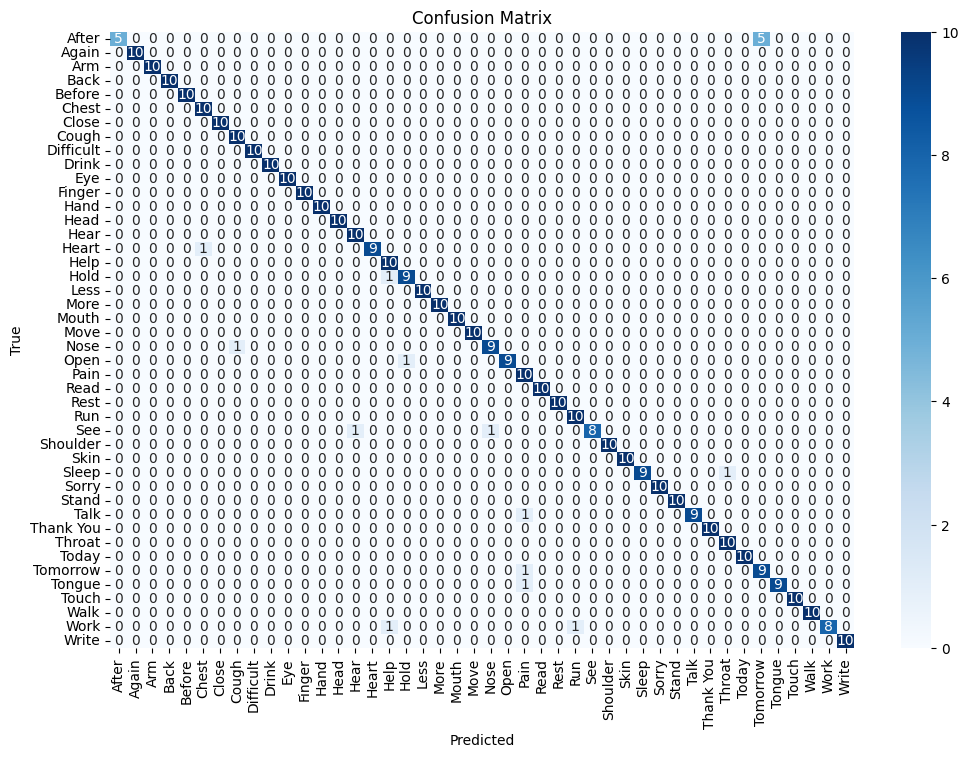

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(12,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

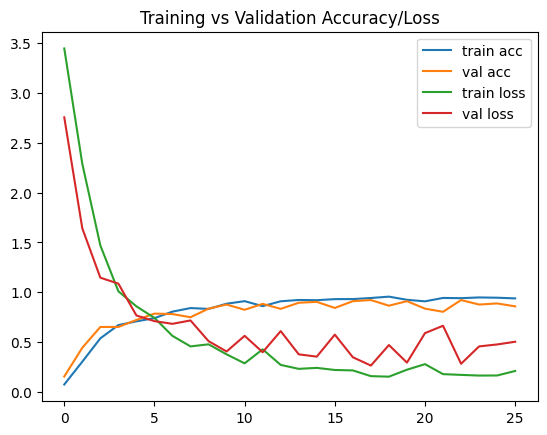

In [52]:
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Training vs Validation Accuracy/Loss")
plt.show()